In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

n = 8                                                   
N = 2**n                                               
n_reduce0 = 3                                          
n_reduce1 = 4
n_reduce2 = 5
N_reduce0 = 2**n_reduce0                                
N_reduce1 = 2**n_reduce1 
N_reduce2 = 2**n_reduce2
t = 5                                                   
dt = 0.01                                              
steps = int(t/dt) + 1                                   
x_max = 10                                             
x = np.linspace(-x_max, x_max, N, endpoint=False)      
dx = x[1] - x[0]                                        
                        
freq = np.fft.fftfreq(N, dx)                            
k = 2 * np.pi * freq                                    
k_shift  = np.fft.fftshift(k)                           
L_half = np.exp(-1j * k**2 * dt/4)                      

In [ ]:

def initial_state_soliton(x, beta=1/2, xc=0.0, v=2.0):
    profile = 1.0 / np.cosh(beta * (x - xc))


    A = 1.0 / np.linalg.norm(profile)

    psi = A * profile * np.exp(1j *0.5 * v * (x - xc))

    g = - beta**2 / A**2
    return psi, g, A

In [ ]:

def ssfm(psi, g, dt, k, L_half):
    psi = np.fft.ifft(np.fft.fft(psi) * L_half)         
    psi = psi*np.exp(- g*1j * np.abs(psi)**2 * dt)      
    psi = np.fft.ifft(np.fft.fft(psi) * L_half)         

    return psi

In [ ]:

def filtering(modes, N, N_reduce):

    half = N_reduce // 2
    filtered_modes = np.zeros(N , dtype=complex)
    filtered_modes[:half] = modes[:half]          
    filtered_modes[-half:] = modes[-half:]        

    return filtered_modes

In [ ]:

def filtered_ssfm(psi, g, dt, k, L_half, N, N_reduce):
    psi = np.fft.fft(psi) * L_half                    
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(modes)

    psi *= np.exp(-g* 1j * np.abs(psi)**2 * dt)        

    psi = np.fft.fft(psi) * L_half                      
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(modes)
    return psi

In [ ]:

def filtered_qssfm(psi, g, dt, k, L_half, N, N_reduce):
    psi = np.fft.fft(psi) * L_half                                 
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(psi)

  
    nonlinear_term = np.fft.ifft(modes)
    psi *= np.exp(-g* 1j * np.abs(nonlinear_term)**2 * dt)         

    psi = np.fft.fft(psi) * L_half                                  
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(psi)
    return psi

In [ ]:

def percent_k(psi_ssfm, psi_qssfm, N, N_reduce):
    a = np.fft.fft(psi_ssfm)
    b = np.fft.fft(psi_qssfm) 
    b = filtering(b, N, N_reduce)
    eta = np.sum(np.abs(b)**2) / np.sum(np.abs(a)**2)
    
    return eta

In [ ]:

def error(psi, psi_exact):
    rho_exact = np.abs(psi_exact)**2
    rho1 = np.abs(psi)**2
    error = np.sqrt(np.sum((rho1 - rho_exact)**2) / np.sum(rho_exact**2))
    return error

In [ ]:

def k_space_filtering(N, N_reduce, k_shift, psi):
    center = N // 2
    half = N_reduce // 2
    freq_origin = np.fft.fftshift(np.fft.fft(psi))
    k_reduce = np.zeros(N_reduce)
    freq_reduce = np.zeros(N_reduce, dtype=complex)
    k_reduce[:] = k_shift[center-half:center+half]         
    freq_reduce[:] = freq_origin[center-half:center+half]  

    return freq_origin, k_reduce, freq_reduce

In [ ]:

if __name__ == "__main__":


    psi0, g, A = initial_state_soliton(x)
    psi1 = np.copy(psi0)
    psi2 = np.copy(psi0)
    psi_exact = np.copy(psi0)
    psi0density_history = [np.abs(psi0)**2/A**2]                                                                            
    psi1density_history = [np.abs(psi1)**2/A**2]                                                                           
    psi2density_history = [np.abs(psi2)**2/A**2]                                                                            
    psi_exactdensity_history = [np.abs(psi_exact)**2/A**2]                                                                        
    times = [0]                                                                                       
    error_history0 = [error(psi0/A, psi_exact/A)]                                                                               
    error_history1 = [error(psi1/A, psi_exact/A)]                                                                              
    error_history2 = [error(psi2/A, psi_exact/A)]                                                                           

    etam3 = [percent_k(psi_exact, psi0, N, N_reduce0)]
    etam4 = [percent_k(psi_exact, psi1, N, N_reduce1)]  
    etam5 = [percent_k(psi_exact, psi2, N, N_reduce2)]    

    freq_n8, k_re_n3, freq_re_n3 = k_space_filtering(N, N_reduce0, k_shift, psi0/A)                       
    freq_n8, k_re_n4, freq_re_n4 = k_space_filtering(N, N_reduce1, k_shift, psi1/A)                       
    freq_n8, k_re_n5, freq_re_n5 = k_space_filtering(N, N_reduce2, k_shift, psi2/A)                       

    for i in range(steps):
        psi_exact = ssfm(psi_exact, g, dt, k, L_half)                                                  
        psi0 = filtered_qssfm(psi0, g, dt, k, L_half, N, N_reduce0)
        psi1 = filtered_qssfm(psi1, g, dt, k, L_half, N, N_reduce1)
        psi2 = filtered_qssfm(psi2, g, dt, k, L_half, N, N_reduce2)

        times.append((i + 1)*dt)                                                                             
        psi0density_history.append(np.abs(psi0)**2/A**2)                                                
        psi1density_history.append(np.abs(psi1)**2/A**2)                                                    
        psi2density_history.append(np.abs(psi2)**2/A**2)                                                 
        psi_exactdensity_history.append(np.abs(psi_exact)**2/A**2)                                     
        error_history0.append(error(psi0, psi_exact))                                                  
        error_history1.append(error(psi1, psi_exact))                                                  
        error_history2.append(error(psi2, psi_exact))                                                   
        etam3.append(percent_k(psi_exact, psi0, N, N_reduce0))
        etam4.append(percent_k(psi_exact, psi1, N, N_reduce1))
        etam5.append(percent_k(psi_exact, psi2, N, N_reduce2))

    np.savez(f"1D-m-effect.npz",    
            times=times,
            psi_m3=psi0density_history,
            psi_m4=psi1density_history,
            psi_m5=psi2density_history,
            rel_l2_err_m3=error_history0,
            rel_l2_err_m4=error_history1,
            rel_l2_err_m5=error_history2,
            etam3 = etam3,
            etam4 = etam4,
            etam5 = etam5,
            ) 
    np.savez(f"1D-m-effect-k.npz",
            k_shift=k_shift,
            freq_n8=np.abs(freq_n8),
            k_re_n3=k_re_n3,
            k_re_n4=k_re_n4,
            k_re_n5=k_re_n5,
            freq_re_n3=np.abs(freq_re_n3),
            freq_re_n4=np.abs(freq_re_n4),
            freq_re_n5=np.abs(freq_re_n5)
            )

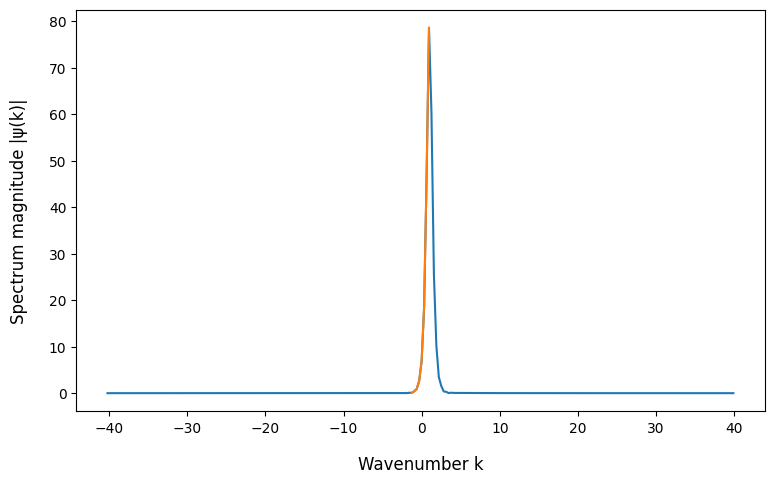

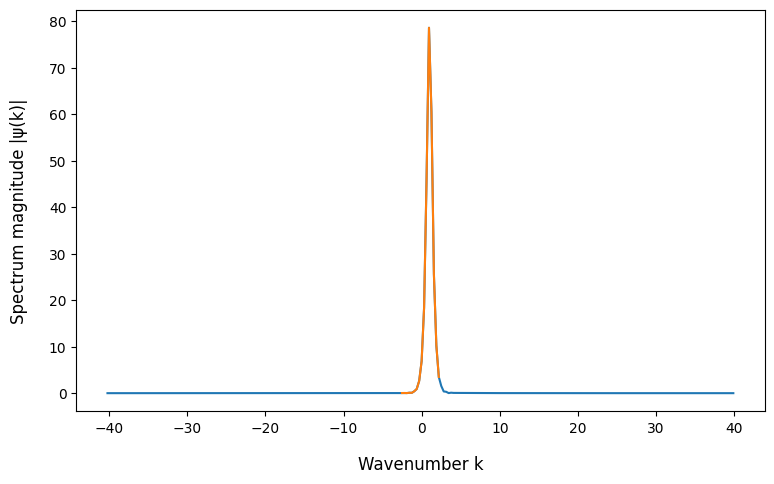

In [43]:
plt.figure(figsize = (8,5))
plt.xlabel('Wavenumber k', fontsize = 12, labelpad = 15)
plt.ylabel('Spectrum magnitude |ψ(k)|', fontsize = 12, labelpad = 15) 
plt.tight_layout()
plt.plot(k_shift,np.abs(freq_n8))
plt.plot(k_re_n3,np.abs(freq_re_n3))
plt.show()

plt.figure(figsize = (8,5))
plt.xlabel('Wavenumber k', fontsize = 12, labelpad = 15)
plt.ylabel('Spectrum magnitude |ψ(k)|', fontsize = 12, labelpad = 15) 
plt.tight_layout()
plt.plot(k_shift,np.abs(freq_n8))
plt.plot(k_re_n4,np.abs(freq_re_n4))
plt.show()

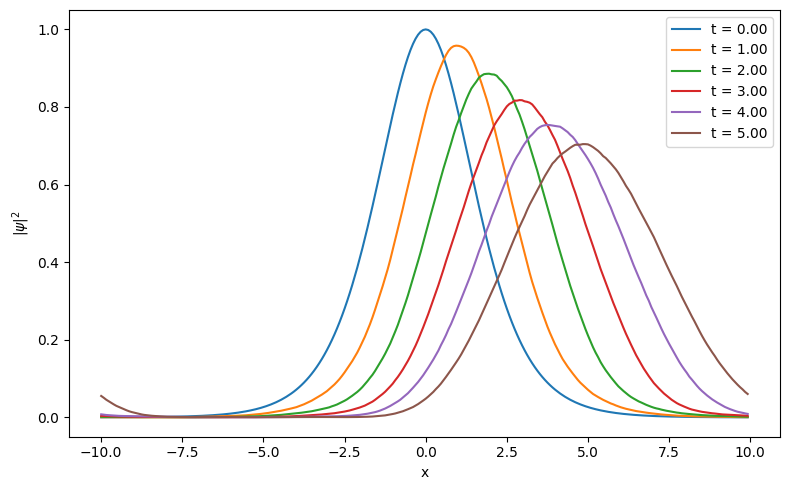

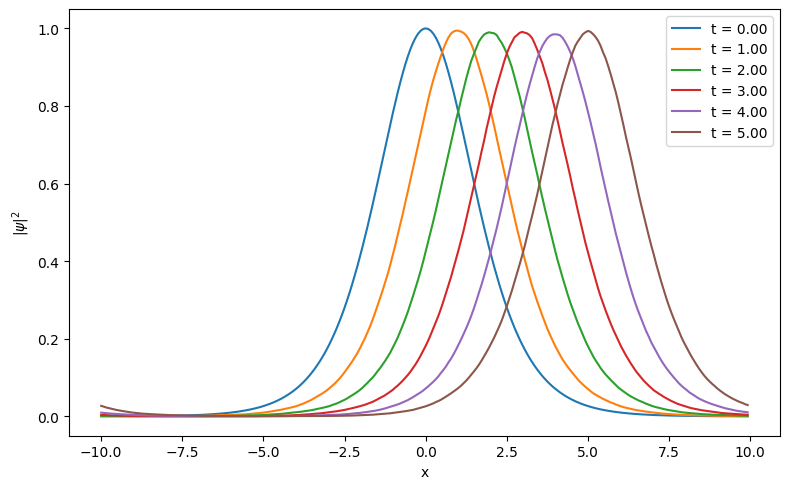

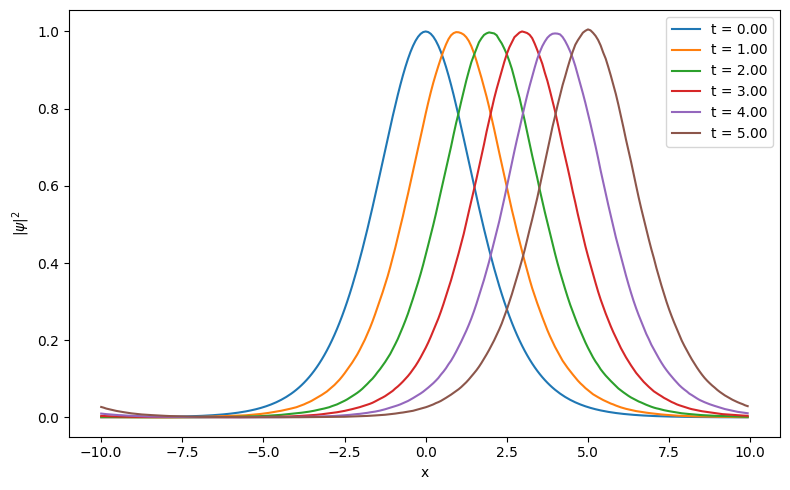

In [ ]:
plt.figure(figsize=(8, 5))

for step in range(len(times)):
    if step % 100 == 0:
        plt.plot(x, psi0density_history[step], label=f"t = {times[step]:.2f}")

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 5))

for step in range(len(times)):
    if step % 100 == 0:
        plt.plot(x, psi1density_history[step], label=f"t = {times[step]:.2f}")

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 5))

for step in range(len(times)):
    if step % 100 == 0:
        plt.plot(x, psi2density_history[step], label=f"t = {times[step]:.2f}")

plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()
plt.show()


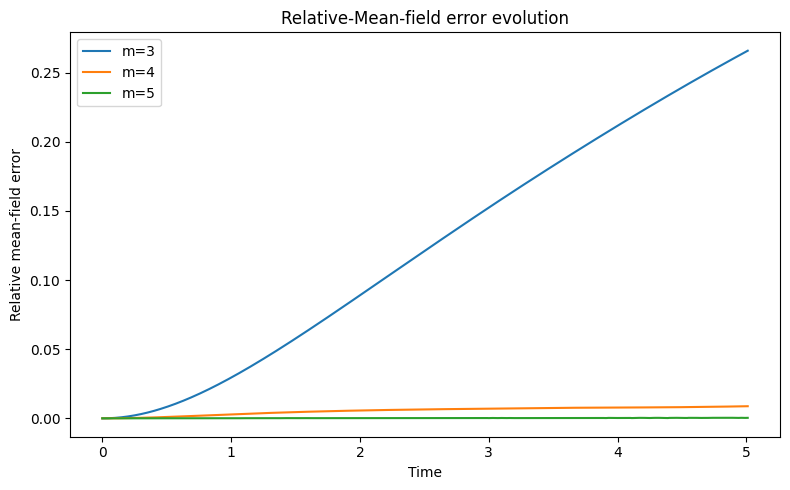

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(times, error_history0, label='m=3')
plt.plot(times, error_history1, label='m=4')
plt.plot(times, error_history2, label='m=5')

plt.xlabel('Time')
plt.ylabel('Relative mean-field error')

plt.legend()
plt.title('Relative-Mean-field error evolution')
plt.tight_layout()

plt.show()